In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import HelmholtzBiperiodic
import HelmholtzChannel
import Chebyshev

# Tests des solveurs de Helmholtz
## Cas périodique


On résout 
$$
(\partial_x^2 + \partial_y^2 -\alpha^2)\psi = S
$$
Avec $x\in [0, 2\pi]$, $y \in [0, 2\pi]$, $\alpha^2 = 2$. Pour $\psi(x, y) = \cos{2x}\sin{2y}$, cela donne 
$$
(-(4+4)-2)\psi = -10\psi = S
$$
D'où $S = -10\cos{2x}\sin{2y}$

x_inf = 0.0, x_sup = 6.283185307179586
y_inf = 0.0, y_sup = 6.283185307179586
Elliptic solver choosen : HelmholtzBiperiodic
err [[1.90020459e-16 1.94289029e-16 1.11022302e-16 ... 8.88178420e-16
  4.71844785e-16 1.94289029e-16]
 [1.94865110e-16 1.94289029e-16 1.38777878e-16 ... 9.43689571e-16
  4.71844785e-16 9.71445147e-17]
 [1.94769766e-16 1.80411242e-16 1.66533454e-16 ... 9.43689571e-16
  4.99600361e-16 1.52655666e-16]
 ...
 [1.55100051e-16 1.11022302e-16 8.32667268e-17 ... 8.32667268e-16
  4.99600361e-16 1.11022302e-16]
 [1.68339219e-16 1.66533454e-16 1.11022302e-16 ... 9.43689571e-16
  3.88578059e-16 1.24900090e-16]
 [1.53926576e-16 1.38777878e-16 8.32667268e-17 ... 8.88178420e-16
  4.44089210e-16 9.71445147e-17]], min = 0.0, max = 9.992007221626409e-16, mediane = 1.1102230246251565e-16


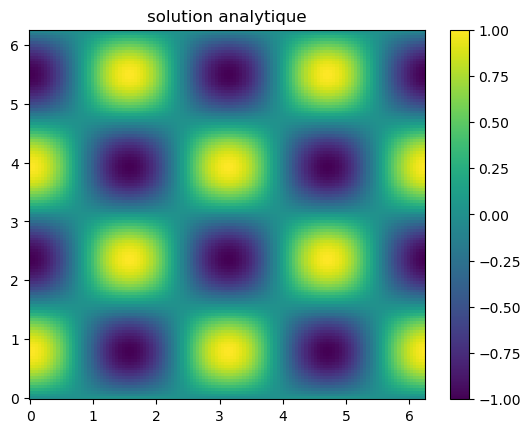

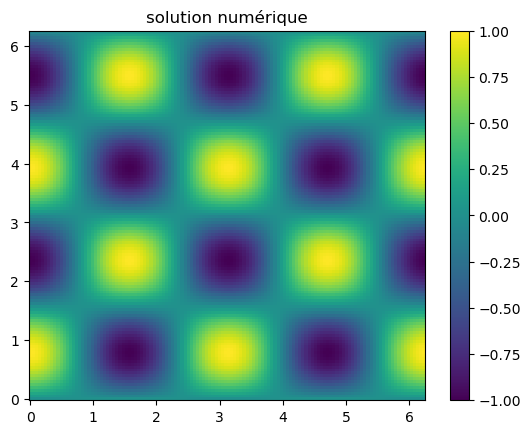

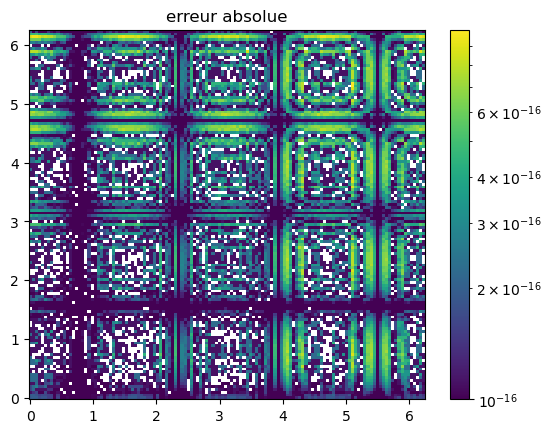

In [3]:
Nx = 128
Ny = 128

x_inf = 0.0
y_inf = 0.0

x_sup = 2.0*np.pi
y_sup = 2.0*np.pi


x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = np.linspace(y_inf, x_sup, Ny, endpoint = False)



print(f"x_inf = {x_inf}, x_sup = {x_sup}")
print(f"y_inf = {y_inf}, y_sup = {y_sup}")

X, Y = np.meshgrid(x, y, indexing= 'ij')

k = 2.0
l=2.0


#rhs = -6.0*np.cos(2.0*X)

alpha2 = 2.0
rhs = (-k**2-l**2-alpha2)*np.cos(k*X)*np.sin(l*Y)
sol_ana = np.cos(k*X)*np.sin(l*Y)
#rhs = (-k**2-alpha2)*np.cos(k*X)
#sol_ana = np.cos(k*X)


Fourier_solver = HelmholtzBiperiodic.HelmholtzBiperiodic(Nx, Ny, x_bounds = (x_inf, x_sup), y_bounds = (y_inf, y_sup))
#sol_num = Fourier_solver.Solve(rhs, alpha2)
Fourier_solver.alpha2 = ('alpha2', 2.0)
sol_num = Fourier_solver.Solve(rhs, 'alpha2')


fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, sol_ana, vmin = -1.0, vmax = 1.0)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y,sol_num, vmin = -1.0, vmax = 1.0)
fig.colorbar(cf, ax=ax)

err = np.abs(sol_ana - sol_num)
print(f"err {err}, min = {err.min()}, max = {err.max()}, mediane = {np.median(err)}")

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err, norm=colors.LogNorm(vmin=1.0e-16, vmax=err.max()))
fig.colorbar(cf, ax=ax)

## Configuration "canal"

On résout 
$$
\left(\partial_y^2+\partial_x^2-\alpha^2\right)\psi(x, y) = RHS(x, y)
$$
sur $x, y \in [-1, 1]$, avec $\psi(x, y=\pm 1) = \cosh(l)\cos(kx)$. La solution est $\psi(x, y) = \cos(kx)\cosh(ly)$ pour $\alpha^2 = k^2-l^2$ et $RHS = \left(l^2 -k^2 - \alpha^2\right)\cos{kx}\cosh{ly}$
Ici, $\alpha^2 = 3$, $k=2$, $l=1$, ce qui donne $RHS = -6\cos{kx}\cosh{ly}$

Nx = 128
Ny = 128
X.shape (128, 128)
Y.shape (128, 128)
alpha^2 2.0
Elliptic solver choosen : HelmholtzChannel
Matrix factorisation
Matrix's size in memory : 15.57 MiB
erreur min = 0.0, max = 1.192379528447418e-13, mediane = 1.4432899320127035e-14


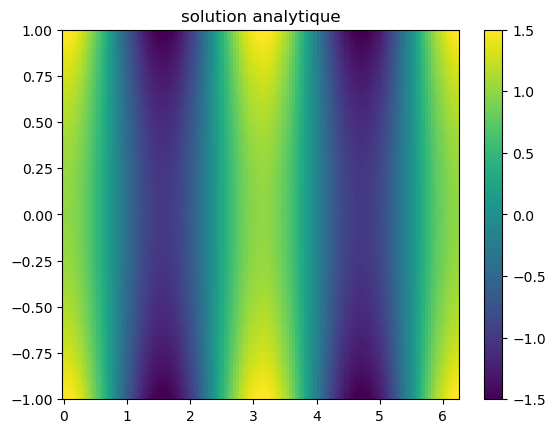

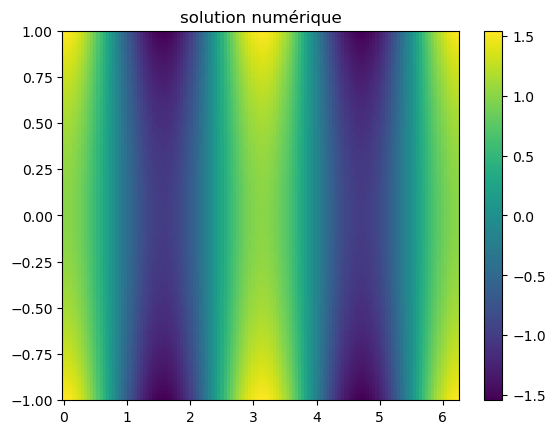

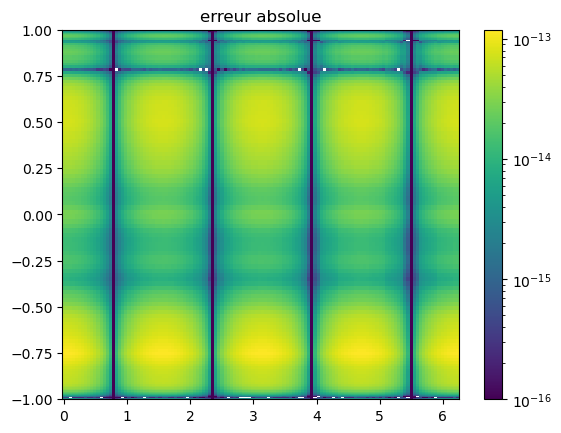

In [4]:
Nx= 128
Ny = 128
x_inf = 0.0
x_sup = 2.*np.pi

y_inf = -1.0
y_sup = 1.0

print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = Chebyshev.collocation_points(Ny, a=y_inf, b=y_sup)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2_2 = 3.0

print(f'alpha^2 {alpha2}')

bc_y1_2 = np.cos(k*x)*np.cosh(l)
bc_ym1_2 = np.cos(k*x)*np.cosh(l)

psi_analytique_2 = np.cos(k*X)*np.cosh(l*Y)
#psi_analytique_2 = np.cos(k*X)*np.sinh(l*Y)

rhs_2 = (l**2-k**2-alpha2_2)*np.cos(k*X)*np.cosh(l*Y)
#rhs_2 = -6.0*np.cos(k*X)*np.sinh(l*Y)
#rhs_2 = np.zeros((Nx, Ny))
ChannelSolver = HelmholtzChannel.HelmholtzChannel(Nx, Ny, x_bounds = (x_inf, x_sup), y_bounds = (y_inf, y_sup))

ChannelSolver.alpha2 = ('alpha2', alpha2_2)

psi_num_2 = ChannelSolver.Solve(rhs_2, 'alpha2', bc_ym1_2, bc_y1_2)

VMAX = max(psi_analytique_2.max(), psi_num_2.max())
VMIN = min(psi_analytique_2.min(), psi_num_2.min())

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique_2, vmin = -1.5, vmax = 1.5)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num_2, vmin = VMIN, vmax = VMAX)
fig.colorbar(cf, ax=ax)

err_2 = np.abs(psi_analytique_2 - psi_num_2)
print(f"erreur min = {err_2.min()}, max = {err_2.max()}, mediane = {np.median(err_2)}")
fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err_2, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_2.max()))
fig.colorbar(cf, ax=ax)

In [5]:
%timeit ChannelSolver.Solve(rhs_2, 'alpha2', bc_ym1_2, bc_y1_2)

9.45 ms ± 1.12 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
